# Loading the full cleaned dataset

In [1]:
import pandas as pd

df = pd.read_csv('all_courses_cleaned.csv')
df.head()

,rating_workload,rating_content,rating_teaching,rating_grading,has_midterm,has_final,has_quiz,has_assignment,has_essay,has_project,...,has_reading,has_presentation,course_name,level,upvote_ratio,instructor_rating,comment_content,comment_teaching,comment_workload,comment_grading
0,4,5,4,4,False,True,True,False,False,True,...,False,False,COMP1001,1000,NaN,0.0,The course is relatively easy and feels very s...,"Not that important, as mentioned lecture conte...","Weekly Labs Assignment: straightforward, can b...",Grade Weighting:<br />Lab Exam: 40%<br />Proje...
1,3,3,3,3,True,True,False,False,False,True,...,False,False,COMP1001,1000,NaN,0.0,"The course is very beginner friendly, and disc...","Unlike other classes, the lectures aren&#039;t...","Workload is manageable, just scope the final p...",Grading is fair: multiple choice quizzes about...
2,5,5,4,5,False,True,True,False,False,True,...,True,True,COMP1001,1000,NaN,0.0,Content covers a few basic useful software lik...,ok ge,"not much workload, a bit busy near the project...","Not sure about the grading, but since most stu..."
3,5,5,5,5,False,True,True,False,False,True,...,False,True,COMP1001,1000,NaN,0.0,中學ICT野，讀過嘅基本上唔使睇lecture notes<br />冇讀都唔緊要，只係肯花...,"冇睇過佢啲lec video, 聽人講佢教書係麻麻嘅，但係呢科嘅內容應該唔需要睇video,...","每星期有一份5題嘅lecture quiz mc, 可以睇住notes做，只要夠小心就一定滿...","好好grade, 就算唔認真讀，只係肯花時間整proj都一定有b range<br />應該..."
4,4,5,5,5,False,True,True,True,False,True,...,False,True,COMP1001,1000,NaN,0.0,Content covers a few useful software like all ...,I think the teaching style is unique and quite...,Workload may be slightly heavy to create a goo...,"Overall, I think it&#039;s great. As long as y..."


In [2]:
df.info()
# contains null values in the columns of 'upvote_ratio' and 'instructor_rating'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1936 entries, 0 to 1935
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating_workload    1936 non-null   int64  
 1   rating_content     1936 non-null   int64  
 2   rating_teaching    1936 non-null   int64  
 3   rating_grading     1936 non-null   int64  
 4   has_midterm        1936 non-null   bool   
 5   has_final          1936 non-null   bool   
 6   has_quiz           1936 non-null   bool   
 7   has_assignment     1936 non-null   bool   
 8   has_essay          1936 non-null   bool   
 9   has_project        1936 non-null   bool   
 10  has_attendance     1936 non-null   bool   
 11  has_reading        1936 non-null   bool   
 12  has_presentation   1936 non-null   bool   
 13  course_name        1936 non-null   object 
 14  level              1936 non-null   int64  
 15  upvote_ratio       1197 non-null   float64
 16  instructor_rating  1618 

In [3]:
df.describe()

,rating_workload,rating_content,rating_teaching,rating_grading,level,upvote_ratio,instructor_rating
count,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1197.000000,1618.000000
mean,3.745868,4.158574,4.152376,4.065083,2392.045455,0.584859,6.767614
std,1.175760,1.017246,1.086932,1.111323,1224.098571,0.411085,5.000719
min,1.000000,1.000000,1.000000,1.000000,1000.000000,0.000000,0.000000
25%,3.000000,4.000000,4.000000,4.000000,1000.000000,0.125000,0.000000
50%,4.000000,4.000000,5.000000,4.000000,2000.000000,0.666667,11.000000
75%,5.000000,5.000000,5.000000,5.000000,3000.000000,1.000000,11.000000
max,5.000000,5.000000,5.000000,5.000000,5000.000000,1.000000,11.000000


# Prepare the Data for Training

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(['rating_content', 'rating_content', 'rating_teaching', 'rating_grading'], axis=1) # drop the columns of ratings to be used as targets
y = df['rating_workload'] # we will only focus on predicting the workload rating

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify to maintain the same distribution of workload ratings in train and test sets
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1548, 18) (388, 18) (1548,) (388,)


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

numerical_features = ['upvote_ratio', 'instructor_rating']
categorical_features = list(X.select_dtypes(include=['bool']).columns)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # choosing median because the mean will be skewed by the few very popular comments with a lot of upvotes, which will have a higher chance of receiving more upvotes as they will be shown at the top
    # ('scaler', StandardScaler()) # some samples will have their 'upvote_ratio' computed to be less than 0
    # ('scaler', MinMaxScaler()) # we don't want to scale 'upvote_ratio' to the range 0-1 or else most of the reviews will get the same 'upvote_ratio' value after imputation
])

cat_pipeline = Pipeline([ 
    # no need for imputation because all columns are complete
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # 'level' = 1000 is NOT being dropped to avoid multicollinearity because it will be used to create new features later on
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, ['level']), # 'level' is the only features that needs to be one-hot encoded; the other features are already binary variables
    ('binary_cat', 'passthrough', categorical_features)
], remainder='drop')

# make sure to fit the preprocessor only on the training data to avoid data leakage
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
df_preprocessed = pd.DataFrame(X_train_preprocessed, columns=preprocessor.get_feature_names_out())

df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num__upvote_ratio             1548 non-null   float64
 1   num__instructor_rating        1548 non-null   float64
 2   cat__level_1000               1548 non-null   float64
 3   cat__level_2000               1548 non-null   float64
 4   cat__level_3000               1548 non-null   float64
 5   cat__level_4000               1548 non-null   float64
 6   cat__level_5000               1548 non-null   float64
 7   binary_cat__has_midterm       1548 non-null   float64
 8   binary_cat__has_final         1548 non-null   float64
 9   binary_cat__has_quiz          1548 non-null   float64
 10  binary_cat__has_assignment    1548 non-null   float64
 11  binary_cat__has_essay         1548 non-null   float64
 12  binary_cat__has_project       1548 non-null   float64
 13  bin

In [6]:
df_preprocessed.describe()

,num__upvote_ratio,num__instructor_rating,cat__level_1000,cat__level_2000,cat__level_3000,cat__level_4000,cat__level_5000,binary_cat__has_midterm,binary_cat__has_final,binary_cat__has_quiz,binary_cat__has_assignment,binary_cat__has_essay,binary_cat__has_project,binary_cat__has_attendance,binary_cat__has_reading,binary_cat__has_presentation
count,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,0.612019,7.412145,0.306202,0.264858,0.220284,0.156977,0.051680,0.722222,0.901809,0.159561,0.848191,0.028424,0.350775,0.284884,0.059432,0.102713
std,0.327660,4.850250,0.461063,0.441400,0.414572,0.363896,0.221451,0.448048,0.297669,0.366317,0.358951,0.166234,0.477367,0.451505,0.236507,0.303682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.666667,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.857143,11.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Feature Engineering (to create new interacting features)

In [ ]:
# !pip install seaborn

<Axes: >

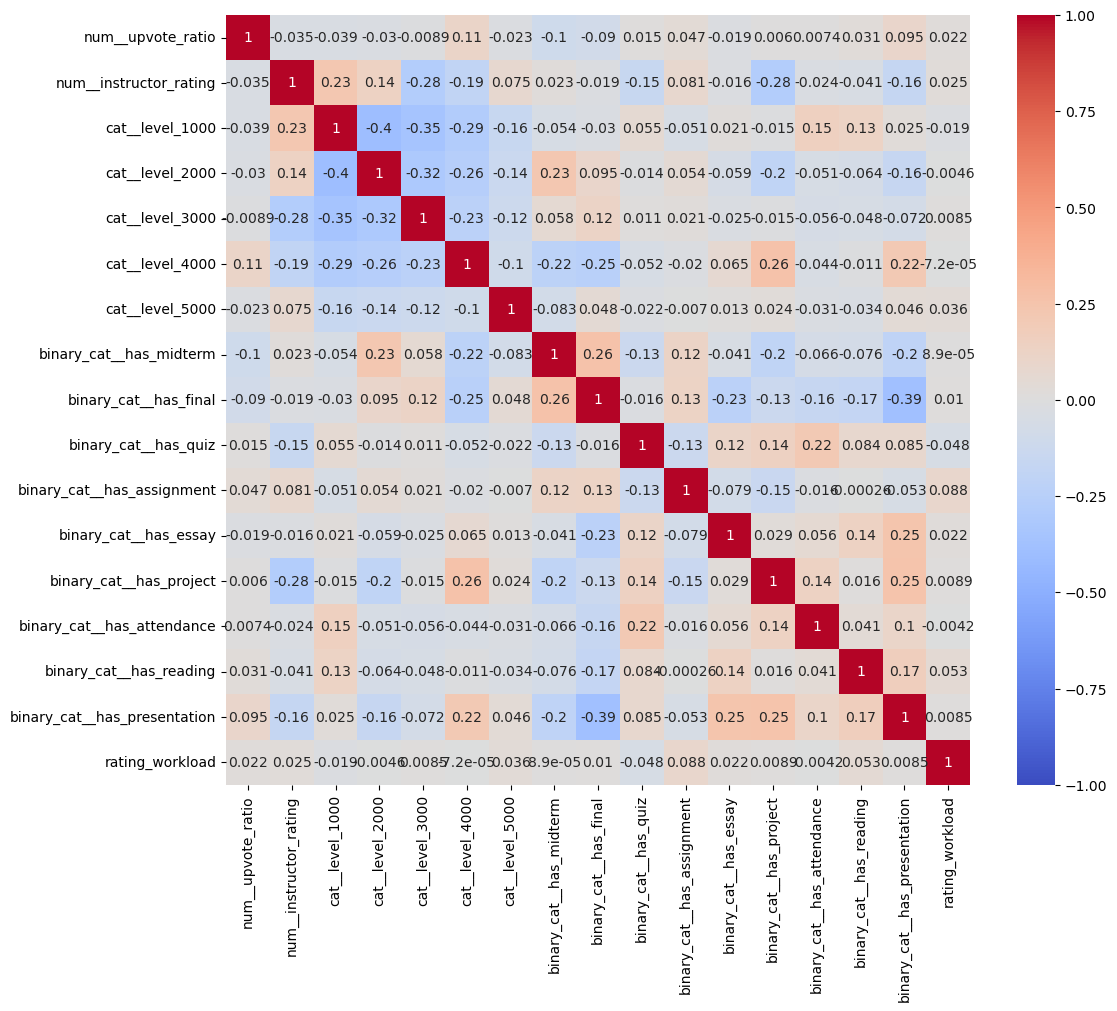

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correlations = pd.concat([df_preprocessed, pd.DataFrame(y_train)], axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# no features seem highly correlated with each other

In [ ]:
# how much 'testing' does a course have?
df_preprocessed['quiz_and_exams'] = df_preprocessed['binary_cat__has_midterm'] + df_preprocessed['binary_cat__has_final'] + df_preprocessed['binary_cat__has_quiz']

# separating the course levels into two different buckets to capture the bigger picture ('is_higher_level' is represented by 'is_lower_level' being 0)
df_preprocessed['is_lower_level'] = (df_preprocessed['cat__level_1000'].astype('bool') | df_preprocessed['cat__level_2000'].astype('bool')).astype('float64')
# df_preprocessed['is_higher_level'] = (df_preprocessed['cat__level_3000'].astype('bool') | df_preprocessed['cat__level_4000'].astype('bool') | df_preprocessed['cat__level_5000'].astype('bool')).astype('float64')

# how much 'workload' does a course have?
df_preprocessed['sum_workload'] = df_preprocessed['binary_cat__has_assignment'] + df_preprocessed['binary_cat__has_project'] + df_preprocessed['binary_cat__has_essay'] + df_preprocessed['binary_cat__has_presentation'] + df_preprocessed['binary_cat__has_reading']

In [ ]:
df_preprocessed.describe()

,num__upvote_ratio,num__instructor_rating,cat__level_1000,cat__level_2000,cat__level_3000,cat__level_4000,cat__level_5000,binary_cat__has_midterm,binary_cat__has_final,binary_cat__has_quiz,binary_cat__has_assignment,binary_cat__has_essay,binary_cat__has_project,binary_cat__has_attendance,binary_cat__has_reading,binary_cat__has_presentation,quiz_and_exams,is_lower_level,sum_workload
count,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,0.612019,7.412145,0.306202,0.264858,0.220284,0.156977,0.051680,0.722222,0.901809,0.159561,0.848191,0.028424,0.350775,0.284884,0.059432,0.102713,1.783592,0.571059,1.389535
std,0.327660,4.850250,0.461063,0.441400,0.414572,0.363896,0.221451,0.448048,0.297669,0.366317,0.358951,0.166234,0.477367,0.451505,0.236507,0.303682,0.668094,0.495085,0.776227
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000
50%,0.666667,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000
75%,0.857143,11.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,2.000000
max,1.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,5.000000


<Axes: >

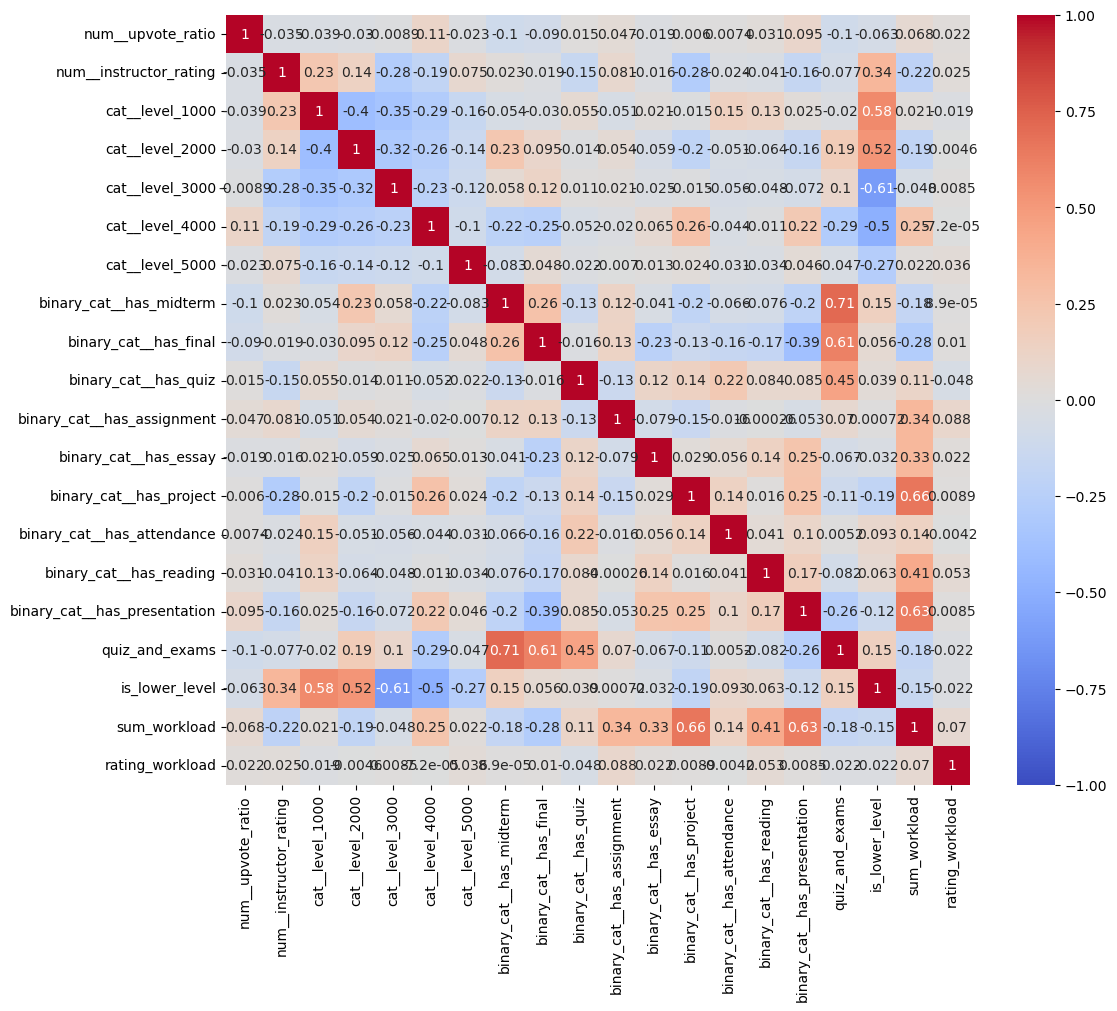

In [ ]:
correlations = pd.concat([df_preprocessed, pd.DataFrame(y_train)], axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [ ]:
# removing features that are now moderately (corr coef >= 0.5) correlated with the new engineered features to avoid multicollinearity
df_preprocessed.drop(columns=['cat__level_1000', 'cat__level_2000', 'cat__level_3000', 'cat__level_4000', 'binary_cat__has_midterm', 'binary_cat__has_final', 'binary_cat__has_project', 'binary_cat__has_presentation'], axis=1, inplace=True)

In [ ]:
correlations = pd.concat([df_preprocessed, pd.DataFrame(y_train)], axis=1).corr()
target_corr = correlations['rating_workload'].sort_values(ascending=False).drop('rating_workload')
target_corr

binary_cat__has_assignment    0.088263
sum_workload                  0.070152
binary_cat__has_reading       0.053425
cat__level_5000               0.035619
num__instructor_rating        0.024822
binary_cat__has_essay         0.022099
num__upvote_ratio             0.021870
binary_cat__has_attendance   -0.004160
is_lower_level               -0.021922
quiz_and_exams               -0.021989
binary_cat__has_quiz         -0.047978
Name: rating_workload, dtype: float64

In [ ]:
# dropping 'num__upvote_ratio' as it would be more helpful when used to determine the quality of the reviews for the NLP model
df_engineered = df_preprocessed.drop(['num__upvote_ratio'], axis=1)

# Explorative Analysis

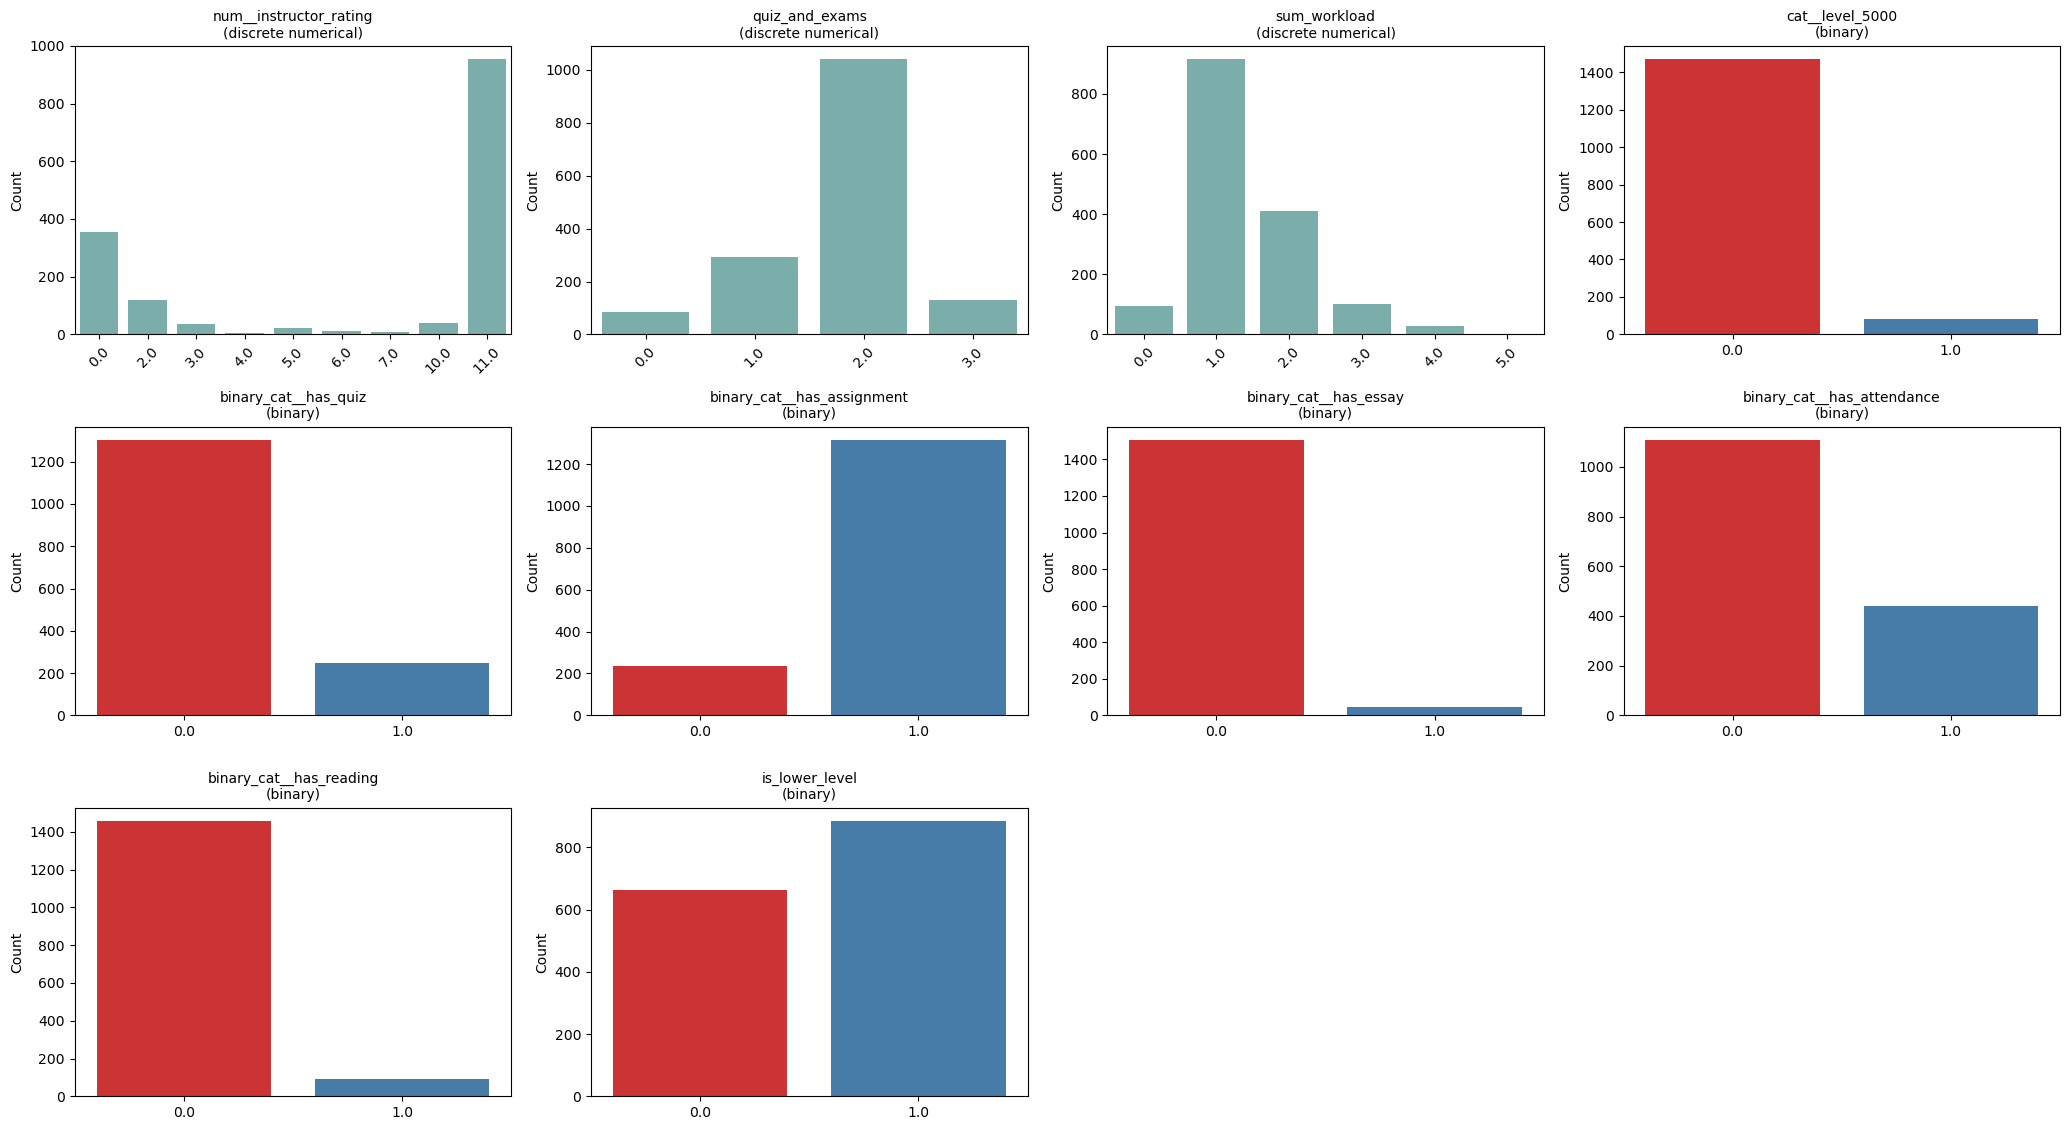

In [ ]:
import numpy as np
import math

# Classify features by type
binary_features = [c for c in df_engineered.columns if df_engineered[c].dropna().nunique() <= 2]
categorical_features = [
    c
    for c in df_engineered.columns
    if str(df_engineered[c].dtype) in ["object", "category"] and c not in binary_features
]
numerical_features = [
    c
    for c in df_engineered.columns
    if pd.api.types.is_numeric_dtype(df_engineered[c]) and c not in binary_features
]

# Treat integer-like, low-cardinality numeric features as discrete and use bar plots for them
max_discrete_levels = 10
discrete_numerical_features = []
for c in numerical_features:
    values = df_engineered[c].dropna()
    unique_count = values.nunique()
    is_integer_like = np.all(np.isclose(values, np.round(values)))
    if is_integer_like and unique_count <= max_discrete_levels:
        discrete_numerical_features.append(c)

continuous_numerical_features = [
    c for c in numerical_features if c not in discrete_numerical_features
]

feature_order = continuous_numerical_features + discrete_numerical_features + categorical_features + binary_features
n_features = len(feature_order)

if n_features == 0:
    print("No features found in df_engineered.")
else:
    ncols = 4
    nrows = math.ceil(n_features / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.2 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feature_order):
        ax = axes[i]
        series = df_engineered[col]

        if col in continuous_numerical_features:
            sns.histplot(series.dropna(), kde=True, bins=20, ax=ax, color="#4C78A8")
            ax.set_title(f"{col}\n(continuous numerical)", fontsize=10)
            ax.set_ylabel("Count")

        elif col in discrete_numerical_features:
            counts = series.value_counts(dropna=False).sort_index()
            sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color="#72B7B2")
            ax.set_title(f"{col}\n(discrete numerical)", fontsize=10)
            ax.tick_params(axis="x", rotation=45)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

        elif col in categorical_features:
            order = series.value_counts(dropna=False).index
            sns.countplot(x=series, order=order, hue=series, legend=False, ax=ax, palette="Set2")
            ax.set_title(f"{col}\n(categorical)", fontsize=10)
            ax.tick_params(axis="x", rotation=45)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

        else:  # binary feature
            order = sorted(series.dropna().unique())
            sns.countplot(x=series, order=order, hue=series, legend=False, ax=ax, palette="Set1")
            ax.set_title(f"{col}\n(binary)", fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("Count")

    # Hide any unused subplot panels
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Most instructors seem to have either a very high or low rating, resulting in a bimodal distribution. Perhaps binning can be helpful to cleanly distinguish the two peaks.
df_engineered['is_instructor_rating_high'] = (df_engineered['num__instructor_rating'] > 0.5)
df_engineered.drop('num__instructor_rating', axis=1, inplace=True)

# It might also be better to exclude the features 'level_5000', 'has_essay', and/or 'has_reading' as they are highly unbalanced and may not provide much useful insights. But this should be done in the hyperparameter tuning section later on.

In [ ]:
df_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cat__level_5000             1548 non-null   float64
 1   binary_cat__has_quiz        1548 non-null   float64
 2   binary_cat__has_assignment  1548 non-null   float64
 3   binary_cat__has_essay       1548 non-null   float64
 4   binary_cat__has_attendance  1548 non-null   float64
 5   binary_cat__has_reading     1548 non-null   float64
 6   quiz_and_exams              1548 non-null   float64
 7   is_lower_level              1548 non-null   float64
 8   sum_workload                1548 non-null   float64
 9   is_instructor_rating_high   1548 non-null   bool   
dtypes: bool(1), float64(9)
memory usage: 110.5 KB


In [ ]:
def build_engineered_features(df_preprocessed_local):
    # Apply the same feature engineering steps.

    df_preprocessed_local['quiz_and_exams'] = (
        df_preprocessed_local['binary_cat__has_midterm']
        + df_preprocessed_local['binary_cat__has_final']
        + df_preprocessed_local['binary_cat__has_quiz']
    )

    df_preprocessed_local['is_lower_level'] = (
        df_preprocessed_local['cat__level_1000'].astype('bool')
        | df_preprocessed_local['cat__level_2000'].astype('bool')
    ).astype('float64')

    df_preprocessed_local['sum_workload'] = (
        df_preprocessed_local['binary_cat__has_assignment']
        + df_preprocessed_local['binary_cat__has_project']
        + df_preprocessed_local['binary_cat__has_essay']
        + df_preprocessed_local['binary_cat__has_presentation']
        + df_preprocessed_local['binary_cat__has_reading']
    )

    df_preprocessed_local.drop(
        columns=[
            'cat__level_1000',
            'cat__level_2000',
            'cat__level_3000',
            'cat__level_4000',
            'binary_cat__has_midterm',
            'binary_cat__has_final',
            'binary_cat__has_project',
            'binary_cat__has_presentation',
        ],
        axis=1,
        inplace=True,
    )

    # df_engineered_local = df_preprocessed_local.drop(['num__upvote_ratio'], axis=1)
    df_preprocessed_local['is_instructor_rating_high'] = (
        df_preprocessed_local['num__instructor_rating'] > 0.5
    )
    df_engineered_local = df_preprocessed_local.drop('num__instructor_rating', axis=1)

    return df_engineered_local


df_test_preprocessed = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out(),
)
df_test_engineered = build_engineered_features(df_test_preprocessed.copy()).drop(['num__upvote_ratio'], axis=1)

df_test_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cat__level_5000             388 non-null    float64
 1   binary_cat__has_quiz        388 non-null    float64
 2   binary_cat__has_assignment  388 non-null    float64
 3   binary_cat__has_essay       388 non-null    float64
 4   binary_cat__has_attendance  388 non-null    float64
 5   binary_cat__has_reading     388 non-null    float64
 6   quiz_and_exams              388 non-null    float64
 7   is_lower_level              388 non-null    float64
 8   sum_workload                388 non-null    float64
 9   is_instructor_rating_high   388 non-null    bool   
dtypes: bool(1), float64(9)
memory usage: 27.8 KB


# Model the Data

In [ ]:
# converting the engineered dataframes back to numpy arrays for model training
X_train = df_engineered.to_numpy()
X_test = df_test_engineered.to_numpy()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1548, 10), (388, 10), (1548,), (388,))

In [ ]:
# starting with a logistic regression model with ovo (resulting in a total of 10 classifiers, a reasonable number of models to train) for multiclass classification
from sklearn.multiclass import OneVsOneClassifier
from sklearn.linear_model import LogisticRegression

ovo_lr = OneVsOneClassifier(LogisticRegression(random_state=42))
ovo_lr.fit(X_train, y_train)

print(f"OVO LogisticRegression Accuracy: {ovo_lr.score(X_test, y_test)}")

OVO LogisticRegression Accuracy: 0.3556701030927835


In [ ]:
# trying a decision tree classifier as well to see if it can outperform logistic regression
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print(f"DecisionTreeClassifier Accuracy: {dt.score(X_test, y_test)}")

DecisionTreeClassifier Accuracy: 0.33505154639175255


In [ ]:
# trying a random forest classifier to see if it can do any better
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print(f"RandomForestClassifier Accuracy: {rf.score(X_test, y_test)}")

RandomForestClassifier Accuracy: 0.34536082474226804


### The accuracy with using mostly binary features and a few quantitative engineered featuers isn't high enough. This is likely due to having exams, assignments, projects, presentations, etc. does not imply a courses's workload will be high (for example, the exams might be open-book, assignments in normal courses usually take a lot less effort to complete than those in honors courses.)

# Adding in NLP

In [ ]:
df = pd.read_csv('all_courses_cleaned.csv')
df[['comment_content', 'comment_teaching', 'comment_workload', 'comment_grading']].head()

,comment_content,comment_teaching,comment_workload,comment_grading
0,The course is relatively easy and feels very s...,"Not that important, as mentioned lecture conte...","Weekly Labs Assignment: straightforward, can b...",Grade Weighting:<br />Lab Exam: 40%<br />Proje...
1,"The course is very beginner friendly, and disc...","Unlike other classes, the lectures aren&#039;t...","Workload is manageable, just scope the final p...",Grading is fair: multiple choice quizzes about...
2,Content covers a few basic useful software lik...,ok ge,"not much workload, a bit busy near the project...","Not sure about the grading, but since most stu..."
3,中學ICT野，讀過嘅基本上唔使睇lecture notes<br />冇讀都唔緊要，只係肯花...,"冇睇過佢啲lec video, 聽人講佢教書係麻麻嘅，但係呢科嘅內容應該唔需要睇video,...","每星期有一份5題嘅lecture quiz mc, 可以睇住notes做，只要夠小心就一定滿...","好好grade, 就算唔認真讀，只係肯花時間整proj都一定有b range<br />應該..."
4,Content covers a few useful software like all ...,I think the teaching style is unique and quite...,Workload may be slightly heavy to create a goo...,"Overall, I think it&#039;s great. As long as y..."


In [ ]:
df[['comment_content', 'comment_teaching', 'comment_workload', 'comment_grading']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1936 entries, 0 to 1935
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   comment_content   1925 non-null   object
 1   comment_teaching  1923 non-null   object
 2   comment_workload  1926 non-null   object
 3   comment_grading   1924 non-null   object
dtypes: object(4)
memory usage: 60.6+ KB


# Data Preparation with NLP

In [ ]:
import re

def is_english(text):
    has_cjk = bool(re.search(r"[\u4e00-\u9fff]", text)) # reject reviews containing CJK characters (since they have diffrent decodings)
    if has_cjk:
        return False
    return True

df_review = df.dropna(subset=['comment_workload'])
df_review = df_review[df_review['comment_workload'].apply(is_english)] # filter for English-only reviews to avoid tokenizing Chinese characters (as they will be interpreted as a single word in the vocabulary)

print(f"Reviews before filtering: {len(df)}")
print(f"Reviews after filtering: {len(df_review)}")
print("Percent reviews filtered out:", (len(df) - len(df_review)) / len(df) * 100, "%")

Reviews before filtering: 1936
Reviews after filtering: 1717
Percent reviews filtered out: 11.31198347107438 %


In [ ]:
df_review.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1717 entries, 0 to 1935
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating_workload    1717 non-null   int64  
 1   rating_content     1717 non-null   int64  
 2   rating_teaching    1717 non-null   int64  
 3   rating_grading     1717 non-null   int64  
 4   has_midterm        1717 non-null   bool   
 5   has_final          1717 non-null   bool   
 6   has_quiz           1717 non-null   bool   
 7   has_assignment     1717 non-null   bool   
 8   has_essay          1717 non-null   bool   
 9   has_project        1717 non-null   bool   
 10  has_attendance     1717 non-null   bool   
 11  has_reading        1717 non-null   bool   
 12  has_presentation   1717 non-null   bool   
 13  course_name        1717 non-null   object 
 14  level              1717 non-null   int64  
 15  upvote_ratio       1029 non-null   float64
 16  instructor_rating  1445 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r"(?u)\b[a-zA-Z]{3,}\b", ngram_range=(1, 2), lowercase=False)  # 'lowercase' set to False because students may use capitalizations for completely different contexts

X = vectorizer.fit_transform(df_review['comment_workload'])

total_words = vectorizer.get_feature_names_out()
print(f"Vocabulary size before frequency filtering: {len(total_words)}")



# we keep only words that occur more than a certain number of times and whether to use only unigrams (two hyperparameters that can be tuned)
frequency_threshold = 7500
ngram = (1, 2) # using both unigrams and bigrams to capture more complex contextual information
vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r"(?u)\b[a-zA-Z]{3,}\b", max_features=frequency_threshold, ngram_range=ngram, lowercase=False)

X = vectorizer.fit_transform(df_review['comment_workload'])

total_words = vectorizer.get_feature_names_out()

print(f"Vocabulary size after frequency filtering: {len(total_words)}")
print("Vocabulary (first 100):", total_words[700:800])

Vocabulary size before frequency filtering: 52555
Vocabulary size after frequency filtering: 7500
Vocabulary (first 100): ['That means' 'That nbsp' 'That said' 'The' 'The HWs' 'The PAs' 'The TAs'
 'The assignment' 'The assignments' 'The class' 'The code' 'The content'
 'The course' 'The department' 'The difficult' 'The difficulty' 'The easy'
 'The exam' 'The exams' 'The final' 'The good' 'The grading' 'The group'
 'The heaviest' 'The homework' 'The homeworks' 'The instruction'
 'The instructions' 'The lab' 'The labs' 'The main' 'The major' 'The mid'
 'The midterm' 'The online' 'The overall' 'The presentation' 'The problem'
 'The prof' 'The professor' 'The programming' 'The project' 'The projects'
 'The questions' 'The quizzes' 'The quot' 'The reason' 'The remaining'
 'The sample' 'The second' 'The takes' 'The task' 'The tasks' 'The thing'
 'The time' 'The weekly' 'The work' 'The workload' 'The worst'
 'The written' 'Their' 'Then' 'Theory' 'There' 'There PAs'
 'There assignment' 'There 

In [ ]:
# using the filtered df_review data frame for train_test_split
X = df_review.drop(['rating_content', 'rating_content', 'rating_teaching', 'rating_grading', 'comment_content', 'comment_teaching', 'comment_grading'], axis=1) # drop the columns of ratings to be used as targets
y = df_review['rating_workload'] # we will only focus on predicting the workload rating

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify to maintain the same distribution of workload ratings in train and test sets
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1373, 15) (344, 15) (1373,) (344,)


In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

text_feature = 'comment_workload'
svd_components = 400 # hyperparammeter to tune
text_vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r"(?u)\b[a-zA-Z]{3,}\b", max_features=frequency_threshold, ngram_range=ngram, lowercase=False)

# fit only on the training data to avoid data leakage
X_train_text = text_vectorizer.fit_transform(X_train[text_feature].astype(str))
X_test_text = text_vectorizer.transform(X_test[text_feature].astype(str))

# using TruncatedSVD to reduce the dimensionality of the sparse text features
svd = TruncatedSVD(n_components=svd_components, random_state=42)
X_train_text_svd = svd.fit_transform(X_train_text)
X_test_text_svd = svd.transform(X_test_text)

X_train_preprocessed = hstack([csr_matrix(preprocessor.fit_transform(X_train)), csr_matrix(X_train_text_svd)])
X_test_preprocessed = hstack([csr_matrix(preprocessor.transform(X_test)), csr_matrix(X_test_text_svd)])

feature_names = list(preprocessor.get_feature_names_out()) + [f'text_svd_{i}' for i in range(svd_components)]
df_preprocessed = pd.DataFrame.sparse.from_spmatrix(X_train_preprocessed, columns=feature_names)
df_test_preprocessed = pd.DataFrame.sparse.from_spmatrix(X_test_preprocessed, columns=feature_names)

df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373 entries, 0 to 1372
Columns: 416 entries, num__upvote_ratio to text_svd_399
dtypes: Sparse[float64, 0](416)
memory usage: 6.4 MB


In [ ]:
# applying the same feature engineering steps to the preprocessed nlp dataframes
df_engineered = build_engineered_features(df_preprocessed.copy())
df_test_engineered = build_engineered_features(df_test_preprocessed.copy())

df_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373 entries, 0 to 1372
Columns: 411 entries, num__upvote_ratio to is_instructor_rating_high
dtypes: Sparse[bool, False](1), Sparse[float64, 0](410)
memory usage: 6.3 MB


/var/folders/6k/xn44j90d53g9rnpq8252v8fh0000gn/T/ipykernel_8198/1993367368.py:11: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with the requested dtype. To retain the old behavior, use `obj.astype(SparseDtype(dtype))`
  df_preprocessed_local['cat__level_1000'].astype('bool')
/var/folders/6k/xn44j90d53g9rnpq8252v8fh0000gn/T/ipykernel_8198/1993367368.py:12: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with the requested dtype. To retain the old behavior, use `obj.astype(SparseDtype(dtype))`
  | df_preprocessed_local['cat__level_2000'].astype('bool')
/var/folders/6k/xn44j90d53g9rnpq8252v8fh0000gn/T/ipykernel_8198/1993367368.py:13: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with

In [ ]:
# converting the engineered dataframes back to numpy arrays for model training
X_train = df_engineered.to_numpy()
X_test = df_test_engineered.to_numpy()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1373, 411), (344, 411), (1373,), (344,))

# Model the Data (with NLP features)

In [ ]:
# starting with a logistic regression model with ovo (resulting in a total of 10 classifiers, a reasonable number of models to train) for multiclass classification
from sklearn.multiclass import OneVsOneClassifier
from sklearn.linear_model import LogisticRegression

ovo_lr = OneVsOneClassifier(LogisticRegression(random_state=42))
ovo_lr.fit(X_train, y_train)

print(f"OVO LogisticRegression Accuracy: {ovo_lr.score(X_test, y_test)}")

OVO LogisticRegression Accuracy: 0.42151162790697677


In [ ]:
# trying a decision tree classifier as well to see if it can outperform logistic regression
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print(f"DecisionTreeClassifier Accuracy: {dt.score(X_test, y_test)}")

DecisionTreeClassifier Accuracy: 0.29651162790697677


In [ ]:
# trying a random forest classifier to see if it can do any better
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print(f"RandomForestClassifier Accuracy: {rf.score(X_test, y_test)}")

RandomForestClassifier Accuracy: 0.36627906976744184


### We see an improvement of ~14-20% for the OVO LogisticRegression and RandomForestClassifier model, whereas the DecisionTreeClassifier (and sometimes RandomForestClassifier) model was probably overfitting. Now we're making progress as this is over 100% better than random guessing (an accuracy of ~20%).

# Optimization (Model Selection & Hyperparameter Tuning)

In [ ]:
# !pip install xgboost

In [ ]:
# using the filtered df_review data frame for train_test_split
X = df_review.drop(['rating_content', 'rating_content', 'rating_teaching', 'rating_grading', 'comment_content', 'comment_teaching', 'comment_grading'], axis=1) # drop the columns of ratings to be used as targets
y = df_review['rating_workload'] # we will only focus on predicting the workload rating

X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify to maintain the same distribution of workload ratings in train and test sets
print(X_train_tune.shape, X_test_tune.shape, y_train_tune.shape, y_test_tune.shape)

(1373, 15) (344, 15) (1373,) (344,)


In [ ]:
# deciding the max_depth values of rf to try
depths = [tree.tree_.max_depth for tree in rf.estimators_]
print(depths)

[17, 23, 23, 20, 23, 23, 18, 31, 23, 22, 27, 19, 23, 23, 21, 23, 25, 23, 18, 19, 26, 21, 22, 23, 24, 17, 18, 24, 24, 17, 20, 18, 23, 24, 22, 25, 18, 21, 19, 18, 20, 20, 17, 21, 20, 20, 20, 23, 23, 21, 20, 22, 24, 21, 19, 27, 23, 22, 21, 19, 21, 21, 21, 18, 28, 18, 28, 20, 22, 17, 24, 20, 17, 27, 20, 24, 14, 22, 18, 22, 21, 17, 23, 19, 21, 18, 21, 21, 25, 20, 20, 21, 22, 27, 27, 21, 18, 22, 24, 24]


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

ovo_lr = OneVsOneClassifier(LogisticRegression(random_state=42))
rf = RandomForestClassifier(random_state=42)
ab = AdaBoostClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)

In [ ]:
# help(XGBClassifier)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

text_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', token_pattern=r'(?u)\b[a-zA-Z]{3,}\b', lowercase=False)),
    ('svd', TruncatedSVD(random_state=42)),
])

preprocess_pipe = ColumnTransformer([
    ('tabular', preprocessor, X_train_tune.columns),
    ('text', text_pipe, 'comment_workload'),
], remainder='drop')

# tuning the max_features and ngram_range parameters of the vectorizer as well as the n_components parameter of the SVD too
model_space = {
    'ovo_lr': (
        ovo_lr,
        {
            'preprocess__text__tfidf__max_features': list(range(1200, 1900, 100)) + list(range(4500, 8000, 500)),
            'preprocess__text__tfidf__ngram_range': [(1, 1), (1, 2)],
            'preprocess__text__svd__n_components': range(50, 450, 50),
            'clf__estimator__solver': ['liblinear'], # using liblinear because the default 'lbfgs' solver does not support L1 regularization
            'clf__estimator__penalty': ['l1', 'l2'],
            'clf__estimator__C': [0.01, 0.1, 1.0, 10.0],
        },
    ),
    'rf': (
        rf,
        {
            'preprocess__text__tfidf__max_features': list(range(1200, 1900, 100)) + list(range(4500, 8000, 500)),
            'preprocess__text__tfidf__ngram_range': [(1, 1), (1, 2)],
            'preprocess__text__svd__n_components': range(50, 450, 50),
            'clf__5n_estimators': range(100, 600, 100),
            'clf__max_depth': range(1, 35, 5),
            'clf__min_samples_split': range(2, 10, 2),
        },
    ),
    'ab': (
        ab,
        {
            'preprocess__text__tfidf__max_features': list(range(1200, 1900, 100)) + list(range(4500, 8000, 500)),
            'preprocess__text__tfidf__ngram_range': [(1, 1), (1, 2)],
            'preprocess__text__svd__n_components': range(50, 450, 50),
            'clf__n_estimators': range(50, 300, 50),
            'clf__learning_rate': [0.01, 0.1, 1.0, 10.0],
        },
    ),
    'xgb': (
        xgb,
        {
            'preprocess__text__tfidf__max_features': list(range(1200, 1900, 100)) + list(range(4500, 8000, 500)),
            'preprocess__text__tfidf__ngram_range': [(1, 1), (1, 2)],
            'preprocess__text__svd__n_components': range(50, 450, 50),
            'clf__max_depth': range(3, 18, 3),
            'clf__n_estimators': range(100, 600, 100),
        },
    ),
}

best_models = {}
search_results = []

for model_name, (estimator, param_grid) in model_space.items():
    full_pipe = Pipeline([
        ('preprocess', preprocess_pipe),
        ('feature_engineering', FunctionTransformer(lambda X: build_engineered_features(pd.DataFrame(X, columns=(list(preprocessor.get_feature_names_out()) + [f'text_svd_{i}' for i in range(X.shape[1] - len(preprocessor.get_feature_names_out()))]))).to_numpy(), validate=False)),
        ('clf', estimator),
    ])

    search = RandomizedSearchCV(
        estimator=full_pipe,
        param_distributions=param_grid,
        n_iter=100,
        cv=10,
        scoring='balanced_accuracy', # using balanced_accuracy to account for class imbalance in the target variable
        n_jobs=-1,
        random_state=42,
    )

    if model_name == 'xgb':
        y_train_fit = y_train_tune - y_train_tune.min()
        y_test_eval = y_test_tune - y_test_tune.min()
    else:
        y_train_fit = y_train_tune
        y_test_eval = y_test_tune

    search.fit(X_train_tune, y_train_fit)
    best_models[model_name] = search.best_estimator_

    test_score = search.best_estimator_.score(X_test_tune, y_test_eval)
    search_results.append({
        'model': model_name,
        'best_model': search.best_estimator_,
        'best_params': search.best_params_,
        'cv_best_score': search.best_score_,
        'test_score': test_score,
    })

# 41m 39.2s

/Users/lirenzhang/anaconda3/envs/tensorflow/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


# Final Comparisons & Evaluations

In [ ]:
results_df = pd.DataFrame(search_results).sort_values('cv_best_score', ascending=False) # sorting according to cv_best_score (using 'balanced_accuracy') to avoid model selection based on the performance on the test set
print(results_df['best_params'].tolist())
results_df

[{'preprocess__text__tfidf__ngram_range': (1, 2), 'preprocess__text__tfidf__max_features': 6500, 'preprocess__text__svd__n_components': 100, 'clf__n_estimators': 400, 'clf__max_depth': 12}, {'preprocess__text__tfidf__ngram_range': (1, 2), 'preprocess__text__tfidf__max_features': 1700, 'preprocess__text__svd__n_components': 400, 'clf__estimator__solver': 'liblinear', 'clf__estimator__penalty': 'l1', 'clf__estimator__C': 10.0}, {'preprocess__text__tfidf__ngram_range': (1, 1), 'preprocess__text__tfidf__max_features': 7500, 'preprocess__text__svd__n_components': 100, 'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__max_depth': 15}, {'preprocess__text__tfidf__ngram_range': (1, 2), 'preprocess__text__tfidf__max_features': 1300, 'preprocess__text__svd__n_components': 150, 'clf__n_estimators': 200, 'clf__learning_rate': 1.0}]


,model,best_model,best_params,cv_best_score,test_score
3,xgb,"(ColumnTransformer(transformers=[('tabular',\n...","{'preprocess__text__tfidf__ngram_range': (1, 2...",0.291535,0.421512
0,ovo_lr,"(ColumnTransformer(transformers=[('tabular',\n...","{'preprocess__text__tfidf__ngram_range': (1, 2...",0.287739,0.409884
1,rf,"(ColumnTransformer(transformers=[('tabular',\n...","{'preprocess__text__tfidf__ngram_range': (1, 1...",0.247671,0.406977
2,ab,"(ColumnTransformer(transformers=[('tabular',\n...","{'preprocess__text__tfidf__ngram_range': (1, 2...",0.247056,0.343023


In [ ]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[(item['model'], item['best_model']) for item in search_results[:2]]) # using the two best models based on cv_best_score to create an ensemble model
voting.fit(X_train_tune, y_train_tune)

print(f"VotingClassifier Accuracy: {voting.score(X_test_tune, y_test_tune)}")

VotingClassifier Accuracy: 0.438953488372093


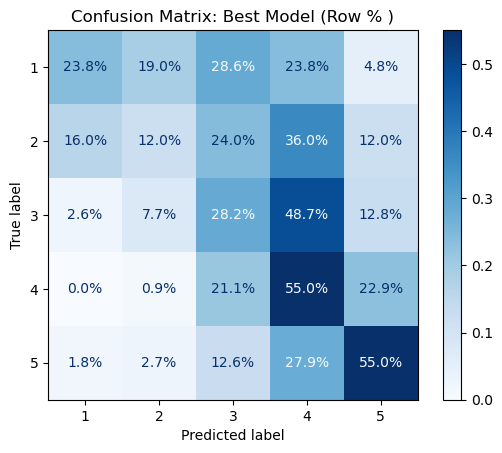

In [ ]:
# drawing the confusion matrix for the best performing model
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

best_model = voting
y_pred = voting.predict(X_test_tune)

labels = [1, 2, 3, 4, 5]
display_labels = ['1', '2', '3', '4', '5']
cm = confusion_matrix(y_test_tune, y_pred, labels=labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap='Blues', values_format='.1%')
plt.title('Confusion Matrix: Best Model (Row % )')
plt.show()

# The model now performs a lot better on rarer classes (with ratings 1-2) and moderately better with workload ratings 3-4, at the cost of a lower performance with workload rating 5.

In [ ]:
# show examples of misclassifed courses' workload ratings and their corresponding comments and correct and predicted ratings

pd.set_option('display.max_colwidth', None)

misclf_pred = best_model.predict(X_test_tune)
misclf_df = X_test_tune.copy()
misclf_df['true_rating'] = y_test_tune.values
misclf_df['pred_rating'] = misclf_pred
misclf_df = misclf_df[misclf_df['true_rating'] != misclf_df['pred_rating']]

def sample_up_to_n(group, n=5, random_state=42):
    if len(group) <= n:
        return group.head(n)
    return group.sample(n=n, random_state=random_state)

misclf_examples = (
    misclf_df
    .sort_values('true_rating')
    .groupby('true_rating', group_keys=False)
    .apply(sample_up_to_n)
    .loc[:, ['comment_workload', 'true_rating', 'pred_rating', 'upvote_ratio']]
    .reset_index(drop=True)
    .sort_values('true_rating')
    .reset_index(drop=True)
)

misclf_examples

,comment_workload,true_rating,pred_rating,upvote_ratio
0,"DO NOT TAKE THIS COURSE!<br /><br />Mid-term/Final:<br />No mid term and final for this semester, so you don&#039;t need to memorize how Dekai Wu is spelt. (To be honest, I think every CS student in HKUST knows his name since he was quite infamous for his teaching, just look at the other reviews)<br /><br />Assignments:<br />Assignments are due in one week ~ 1.5 weeks, and it is quite hard to finish them in time especially if you are year 4 with FYP or took a lot of courses in that semester.<br /><br />Assignment 1: Dijkstra Anagram<br />Assignment requirement is to write a program to do Dijkstra algorithm for generating anagram.<br />This first assignment is okay, not too difficult. <br />But for getting the 5 points bonus it is quite hard, since your program need to run fast enough within 20s for 14 character length word, which required you to use some sort of pruning to achieve that efficiency.<br /><br />Assignment 2: HMM<br />Assignment requires to write a program for Hidden Markov Model backward forward algorithm.<br />This assignment is hard, since the concept and equations of backward and forward algorithm and HMM is quite difficult and complicated. So you need to spend a lot of time to understand it.<br />And with the complicated equations, debugging takes a long time.<br /><br />Assignment 3: Feedforward POS Tagger<br />Assignment requirement is to loop through the scientific method for feed forward part of speech tagger.<br />This assignment is easy in terms of coding, since for every hypothesis, just a few lines of code is needed to be changed.<br />The annoying part is that you would need to write observations of the training set, description of hypothesis, and do error analysis for each hypothesis.<br />And because I didn&#039;t know whether the answers are correct or not, I tried to write as long as possible for the description and explanation, which I used a lot of time to do. I don&#039;t know whether it is necessary to write so long, but in the end I got 100/100<br /><br />Assignment 4: RNN <br />Assignment requirement: create bidirectional RNN, LSTM, and bidirectional LSTM model for tagging part of speech for the training set with the starting code of RNN.<br />I would say this is the most useless and annoying assignment because the machine learning framework used in this assignment is LEGO, which is developed by Dekai and his TAs.<br />Why the hell would you ask the students to use C++ and your own LEGO machine learning framework, but not python with state-of-the-art machine learning framework such as pyTorch or Tensorflow?<br />Not to mention that because the framework is developed by Dekai and his TAs, there are no documentation that you can refer to understand how LEGO actually works.<br />So you would spend a lot of time trying to understand the starting code with the comments, do trial and error to understand how different function works and the output of different variables.<br />Basically, this assignment teaches you to use LEGO machine learning framework, which you would never ever use again in your whole life. (Unless you decide to do postgrad and become his TA)",1,3,0.888889
1,"Each homework will take around 24 hours (plus 2 days to read the lecture notes covered since the last HW each time), and there are 6.<br />Revising for the finals should take at least 3 days.",1,4,0.166667
2,"Tremendous<br />The labs are easy. They would not take more than a day to complete. Even if you find it difficult or you are too busy to deal with it, you can skip it and work for the next one.<br /><br />I would recommend you start doing the PA at least a week before the deadline. It is much harder than you thought to make the program work the way you want. Besides, you need to design test cases for the program yourself if you want to secure a high score.<br /><br />For the project, make good plannings before you and your groupmates start working. Make gradual 

In [ ]:
# apply the mapping from the original ratings (1-5) to the new workload labels ('high', 'medium', 'low') to be used as targets for the final model evaluation to account for the highly subjective boundaries between ratings 1-2 and 4-5
def encode_workload_labels(series):
    series = pd.Series(series)
    mapped = series.map({1: 'high', 2: 'high', 3: 'medium', 4: 'low', 5: 'low'})
    return mapped.map({'low': 0, 'medium': 1, 'high': 2})

y_pred_binned = encode_workload_labels(y_pred)
y_test_binned = encode_workload_labels(y_test_tune)
print(np.unique(y_pred_binned))

[0 1 2]


Binned Accuracy: 0.625


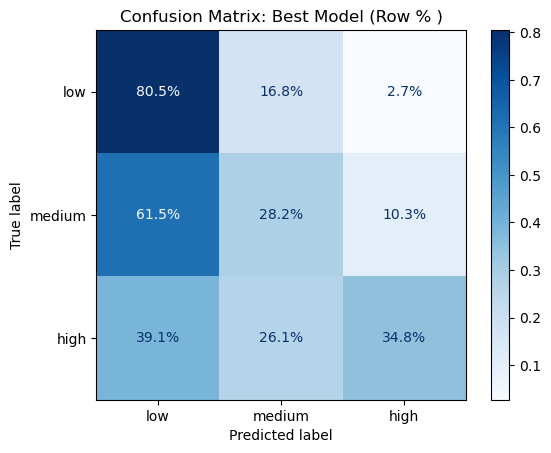

In [ ]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix

binned_accuracy = accuracy_score(y_test_binned, y_pred_binned)
print(f"Binned Accuracy: {binned_accuracy:.3f}")

labels = sorted(pd.unique(y_test_binned))
label_names = {0: 'low', 1: 'medium', 2: 'high'}
display_labels = [label_names.get(label, str(label)) for label in labels]
cm = confusion_matrix(y_test_binned, y_pred_binned, labels=labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap='Blues', values_format='.1%')
plt.title('Confusion Matrix: Best Model (Row % )')
plt.show()

### Conclusion: VotingClassifier built from XGBClassifier and OneVsOneClassifier performed best overall, with a test accuracy of ~43.9% and a final accuracy (after binning 'rating_workload' into 'high', 'medium', 'low') of ~62.5%. The model identified most low workload courses correctly (rating 4-5) and performed worst on the medium workload courses (rating 3).

In [ ]:
pd.set_option('display.max_colwidth', 50)